## Partie 2 — Feature Engineering

In [132]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement du DataFrame depuis la Partie 1
team_matches = pd.read_csv("fact_team_matches_bis.csv")
team_matches["date"] = pd.to_datetime(team_matches["date"])
print("✅ team_matches chargé :", team_matches.shape)

✅ team_matches chargé : (8122, 33)


In [133]:
team_matches['opp_rank_before'][team_matches["matchweek"] == 6]

5       17.0
43      14.0
81      19.0
119      4.0
157     12.0
        ... 
7996     7.0
8022    15.0
8048    20.0
8074    10.0
8100     3.0
Name: opp_rank_before, Length: 220, dtype: float64

In [134]:
# Création variables de seuils, gaps, dummies
MARGIN = 6
PTS_COL = "cum_points_before"
RANK_COL = "rank_before"
keys = ["season_start", "matchweek"]

team_matches = team_matches.sort_values(
    ["season_start", "date", "matchweek", "team", "match_id"]
).copy()


def points_at_rank(df, target_rank):
    tmp = (
        df.loc[df[RANK_COL] == target_rank, keys + [PTS_COL]]
        .drop_duplicates(subset=keys)
        .rename(columns={PTS_COL: f"points_{target_rank}"})
    )
    return tmp


# 1️⃣ récupérer les seuils
p18 = points_at_rank(team_matches, 18)
p4  = points_at_rank(team_matches, 4)
p1  = points_at_rank(team_matches, 1)

team_matches = team_matches.merge(p18, on=keys, how="left")
team_matches = team_matches.merge(p4,  on=keys, how="left")
team_matches = team_matches.merge(p1,  on=keys, how="left")


# 2️⃣ gaps
team_matches["gap_to_18th"] = team_matches[PTS_COL] - team_matches["points_18"]
team_matches["gap_to_4th"]  = team_matches[PTS_COL] - team_matches["points_4"]
team_matches["gap_to_1st"]  = team_matches[PTS_COL] - team_matches["points_1"]


# 3️⃣ dummies
team_matches["within6_of_safety_18th"] = (
    team_matches["gap_to_18th"].abs().fillna(np.inf) <= MARGIN
).astype(int)

team_matches["within6_of_top4_4th"] = (
    team_matches["gap_to_4th"].abs().fillna(np.inf) <= MARGIN
).astype(int)

team_matches["within6_of_title_1st"] = (
    team_matches["gap_to_1st"].abs().fillna(np.inf) <= MARGIN
).astype(int)


# 4️⃣ pressions
team_matches["pressure_safety_18th"] = np.where(
    team_matches["gap_to_18th"].fillna(MARGIN+1) <= 0,
    1.0,
    np.clip(1 - team_matches["gap_to_18th"].fillna(MARGIN+1) / MARGIN, 0, 1)
)

team_matches["pressure_top4_4th"] = np.where(
    team_matches["gap_to_4th"].fillna(MARGIN+1) <= 0,
    1.0,
    np.clip(1 - team_matches["gap_to_4th"].fillna(MARGIN+1) / MARGIN, 0, 1)
)

team_matches["pressure_title_1st"] = np.where(
    team_matches["gap_to_1st"].fillna(MARGIN+1) <= 0,
    1.0,
    np.clip(1 - team_matches["gap_to_1st"].fillna(MARGIN+1) / MARGIN, 0, 1)
)

In [135]:
opp_vars = [
    "mw_id",   # clé commune du match
    "team",
    "gap_to_18th",
    "gap_to_4th",
    "gap_to_1st",
    "within6_of_safety_18th",
    "within6_of_top4_4th",
    "within6_of_title_1st",
    "pressure_safety_18th",
    "pressure_top4_4th",
    "pressure_title_1st",
]

opp = (
    team_matches[opp_vars]
    .drop_duplicates(["mw_id", "team"])
    .rename(columns={
        "team": "opponent",
        "gap_to_18th": "opp_gap_to_18th",
        "gap_to_4th": "opp_gap_to_4th",
        "gap_to_1st": "opp_gap_to_1st",
        "within6_of_safety_18th": "opp_within6_of_safety_18th",
        "within6_of_top4_4th": "opp_within6_of_top4_4th",
        "within6_of_title_1st": "opp_within6_of_title_1st",
        "pressure_safety_18th": "opp_pressure_safety_18th",
        "pressure_top4_4th": "opp_pressure_top4_4th",
        "pressure_title_1st": "opp_pressure_title_1st",
    })
)

team_matches = team_matches.merge(
    opp,
    on=["mw_id", "opponent"],
    how="left",
    validate="m:1"
)

In [137]:
team_matches.columns 

Index(['match_id', 'mw_id', 'season_start', 'matchweek', 'date', 'team',
       'opponent', 'goals_for', 'goals_against', 'attendance', 'venue',
       'referee', 'points', 'cum_points_after', 'cum_points_before',
       'cum_gf_after', 'cum_ga_after', 'cum_gd_after', 'rank_after',
       'rank_before', 'opp_rank_before', 'opp_rank_after', 'form5_points',
       'form5_gf', 'form5_ga', 'form5_gd', 'opp_form5_points', 'opp_form5_gf',
       'opp_form5_ga', 'opp_form5_gd', 'form5_points_diff', 'form5_gd_diff',
       'rank_diff', 'points_18', 'points_4', 'points_1', 'gap_to_18th',
       'gap_to_4th', 'gap_to_1st', 'within6_of_safety_18th',
       'within6_of_top4_4th', 'within6_of_title_1st', 'pressure_safety_18th',
       'pressure_top4_4th', 'pressure_title_1st', 'opp_gap_to_18th',
       'opp_gap_to_4th', 'opp_gap_to_1st', 'opp_within6_of_safety_18th',
       'opp_within6_of_top4_4th', 'opp_within6_of_title_1st',
       'opp_pressure_safety_18th', 'opp_pressure_top4_4th',
       'opp

In [138]:
# 1) Rivalités avec intensité
rivalries_intensity = {
    "forte": [
        ("Arsenal", "Tottenham Hotspur"),
        ("Liverpool", "Everton"),
        ("Manchester United", "Manchester City"),
        ("Manchester United", "Liverpool"),
        ("Newcastle United", "Sunderland"),
        ("Crystal Palace", "Millwall"),
    ],
    "moyenne": [
        ("Arsenal", "Chelsea"),
        ("Chelsea", "Tottenham Hotspur"),
        ("Chelsea", "West Ham United"),
        ("Arsenal", "West Ham United"),
        ("Tottenham Hotspur", "West Ham United"),
        ("Chelsea", "Fulham"),
        ("Fulham", "Brentford"),
        ("Leicester City", "Nottingham Forest"),
        ("Leicester City", "Derby County"),
        ("Derby County", "Nottingham Forest"),
    ],
}

# 2) intensité (paire non orientée)
rivalry_lookup = {}
for intensity, pairs in rivalries_intensity.items():
    for a, b in pairs:
        rivalry_lookup[tuple(sorted([a, b]))] = intensity

# 3) Création de la colonne d'intensité texte 
pairs_series = list(
    zip(
        np.minimum(team_matches["team"].astype(str), team_matches["opponent"].astype(str)),
        np.maximum(team_matches["team"].astype(str), team_matches["opponent"].astype(str)),
    )
)

team_matches["rivalry_intensity"] = [rivalry_lookup.get(p, "neutre") for p in pairs_series]

# 4) Création de de la colonne numérique
intensity_map = {"neutre": 0, "moyenne": 1, "forte": 2}
team_matches["rivalry_intensity_num"] = team_matches["rivalry_intensity"].map(intensity_map).astype(int)


In [139]:
team_matches.columns

Index(['match_id', 'mw_id', 'season_start', 'matchweek', 'date', 'team',
       'opponent', 'goals_for', 'goals_against', 'attendance', 'venue',
       'referee', 'points', 'cum_points_after', 'cum_points_before',
       'cum_gf_after', 'cum_ga_after', 'cum_gd_after', 'rank_after',
       'rank_before', 'opp_rank_before', 'opp_rank_after', 'form5_points',
       'form5_gf', 'form5_ga', 'form5_gd', 'opp_form5_points', 'opp_form5_gf',
       'opp_form5_ga', 'opp_form5_gd', 'form5_points_diff', 'form5_gd_diff',
       'rank_diff', 'points_18', 'points_4', 'points_1', 'gap_to_18th',
       'gap_to_4th', 'gap_to_1st', 'within6_of_safety_18th',
       'within6_of_top4_4th', 'within6_of_title_1st', 'pressure_safety_18th',
       'pressure_top4_4th', 'pressure_title_1st', 'opp_gap_to_18th',
       'opp_gap_to_4th', 'opp_gap_to_1st', 'opp_within6_of_safety_18th',
       'opp_within6_of_top4_4th', 'opp_within6_of_title_1st',
       'opp_pressure_safety_18th', 'opp_pressure_top4_4th',
       'opp

In [140]:
# attendance
team_matches["attendance"] = pd.to_numeric(team_matches["attendance"], errors="coerce")

def classify_attendance_by_season(g: pd.DataFrame) -> pd.DataFrame:
    # quartiles sur la saison (en ignorant les NaN)
    q1, q2, q3 = g["attendance"].quantile([0.25, 0.50, 0.75])

    g = g.copy()
    g["attendance_cat"] = pd.cut(
        g["attendance"],
        bins=[-np.inf, q1, q2, q3, np.inf],
        labels=["faible affluence", "affluence moyenne", "bonne affluence", "grosse affluence"],
        include_lowest=True
    )
    return g

team_matches = (
    team_matches
    .groupby("season_start", group_keys=False)
    .apply(classify_attendance_by_season)
)

# numérique
cat_to_num = {
    "faible affluence": 1,
    "affluence moyenne": 2,
    "bonne affluence": 3,
    "grosse affluence": 4
}
team_matches["attendance_cat_num"] = team_matches["attendance_cat"].map(cat_to_num).astype("Int64")


C:\Users\flere\AppData\Local\Temp\ipykernel_11772\715850295.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify_attendance_by_season)


In [141]:
team_matches[team_matches["matchweek"] == 6]

,match_id,mw_id,season_start,matchweek,date,team,opponent,goals_for,goals_against,attendance,...,opp_within6_of_safety_18th,opp_within6_of_top4_4th,opp_within6_of_title_1st,opp_pressure_safety_18th,opp_pressure_top4_4th,opp_pressure_title_1st,rivalry_intensity,rivalry_intensity_num,attendance_cat,attendance_cat_num
100,2015_6_Arsenal_,J6_2015,2015,6,2015-09-19,Arsenal,Chelsea,0.0,2.0,41584.0,...,1,1,0,0.666667,1.0,1.0,moyenne,1,bonne affluence,3
101,2015_6_Aston Villa_,J6_2015,2015,6,2015-09-19,Aston Villa,West Bromwich Albion,0.0,1.0,36321.0,...,1,1,0,0.500000,1.0,1.0,neutre,0,bonne affluence,3
102,2015_6_Bournemouth_,J6_2015,2015,6,2015-09-19,Bournemouth,Sunderland,2.0,0.0,11271.0,...,1,0,0,1.000000,1.0,1.0,neutre,0,faible affluence,1
103,2015_6_Chelsea_,J6_2015,2015,6,2015-09-19,Chelsea,Arsenal,2.0,0.0,41584.0,...,0,1,1,0.000000,1.0,1.0,moyenne,1,bonne affluence,3
104,2015_6_Everton_,J6_2015,2015,6,2015-09-19,Everton,Swansea City,0.0,0.0,20805.0,...,1,1,0,0.000000,1.0,1.0,neutre,0,faible affluence,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7715,2025_6_Aston Villa_,J6_2025,2025,6,2025-09-28,Aston Villa,Fulham,3.0,1.0,40350.0,...,1,1,0,0.166667,1.0,1.0,neutre,0,bonne affluence,3
7716,2025_6_Fulham_,J6_2025,2025,6,2025-09-28,Fulham,Aston Villa,1.0,3.0,40350.0,...,1,0,0,1.000000,1.0,1.0,neutre,0,bonne affluence,3
7717,2025_6_Newcastle United_,J6_2025,2025,6,2025-09-28,Newcastle United,Arsenal,1.0,2.0,52199.0,...,0,1,1,0.000000,1.0,1.0,neutre,0,bonne affluence,3
7718,2025_6_Everton_,J6_2025,2025,6,2025-09-29,Everton,West Ham United,1.0,1.0,51890.0,...,1,0,0,1.000000,1.0,1.0,neutre,0,bonne affluence,3


C:\Users\flere\AppData\Local\Temp\ipykernel_11772\558338579.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rest_category"] = df["rest_days"].apply(rest_category)


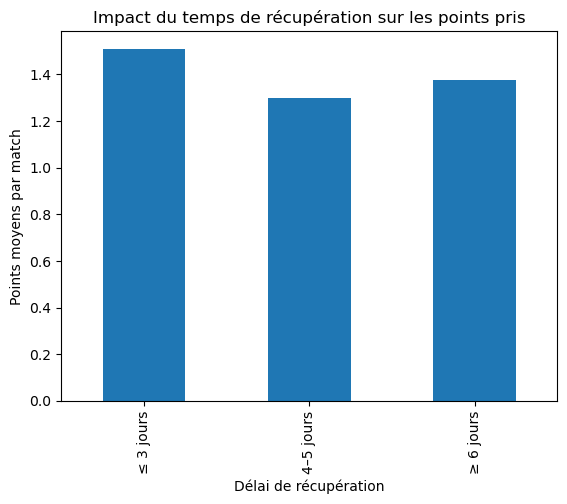

In [142]:
# S'assurer que la date est au bon format
team_matches["date"] = pd.to_datetime(team_matches["date"])

# Calcul du temps de récupération (jours entre deux matchs)
team_matches = team_matches.sort_values(
    ["season_start", "team", "date"]
).copy()

team_matches["rest_days"] = (
    team_matches
    .groupby(["season_start", "team"])["date"]
    .diff()
    .dt.days
)

# On garde uniquement les matchs exploitables
df = team_matches.dropna(subset=["rest_days", "points"])

# Catégorisation des délais de récupération
def rest_category(x):
    if x <= 3:
        return "≤ 3 jours"
    elif x <= 5:
        return "4–5 jours"
    else:
        return "≥ 6 jours"

df["rest_category"] = df["rest_days"].apply(rest_category)

# Points moyens par catégorie
avg_points = (
    df.groupby("rest_category")["points"]
      .mean()
      .reindex(["≤ 3 jours", "4–5 jours", "≥ 6 jours"])
)

# Graphique
plt.figure()
avg_points.plot(kind="bar")
plt.xlabel("Délai de récupération")
plt.ylabel("Points moyens par match")
plt.title("Impact du temps de récupération sur les points pris")
plt.show()


<Figure size 900x500 with 0 Axes>

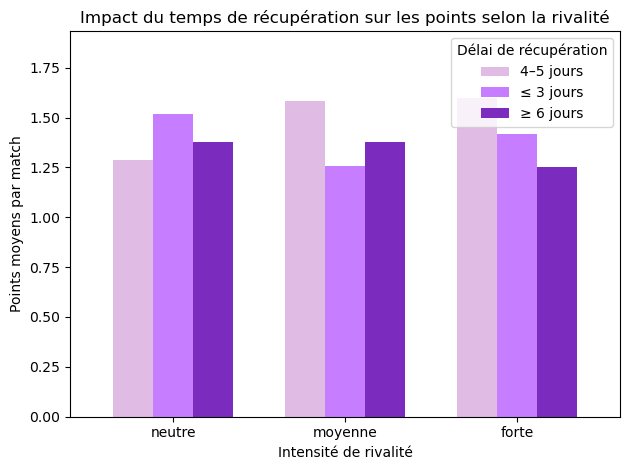

In [143]:
# --- Préparation ---
df = team_matches.dropna(
    subset=["rest_days", "points", "rivalry_intensity"]
).copy()

def rest_category(x):
    if x <= 3:
        return "≤ 3 jours"
    elif x <= 5:
        return "4–5 jours"
    else:
        return "≥ 6 jours"

df.loc[:, "rest_category"] = df["rest_days"].apply(rest_category)

avg_points = (
    df.groupby(["rivalry_intensity", "rest_category"])["points"]
      .mean()
      .unstack()
      .reindex(index=["neutre", "moyenne", "forte"])
)

plt.figure(figsize=(9, 5))

ax = avg_points.plot(
    kind="bar",
    width=0.7,
    color=["#E0BBE4", "#C77DFF", "#7B2CBF"]
)

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.xlabel("Intensité de rivalité")
plt.ylabel("Points moyens par match")
plt.title("Impact du temps de récupération sur les points selon la rivalité")

plt.legend(title="Délai de récupération")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [144]:
#Matrice de corrélation
team_matches.select_dtypes(include="number").corr()

,season_start,matchweek,goals_for,goals_against,attendance,points,cum_points_after,cum_points_before,cum_gf_after,cum_ga_after,...,opp_gap_to_1st,opp_within6_of_safety_18th,opp_within6_of_top4_4th,opp_within6_of_title_1st,opp_pressure_safety_18th,opp_pressure_top4_4th,opp_pressure_title_1st,rivalry_intensity_num,attendance_cat_num,rest_days
season_start,1.000000e+00,-5.841450e-02,0.035564,0.035564,8.549036e-02,0.000958,-0.044684,-0.045323,-0.001659,-0.001763,...,0.070568,-0.066560,0.047032,0.016579,-0.042283,-0.017551,-7.915452e-03,1.360570e-02,-4.996736e-04,-0.007750
matchweek,-5.841450e-02,1.000000e+00,0.008522,0.008522,-1.287629e-02,0.003761,0.807949,0.817981,0.823200,0.874613,...,-0.678359,-0.312304,-0.367747,-0.389492,-0.171462,0.039460,2.779393e-01,-5.357153e-03,1.417706e-02,-0.038695
goals_for,3.556426e-02,8.521793e-03,1.000000,-0.142056,4.067881e-02,0.669134,0.187873,0.141868,0.208016,-0.083748,...,-0.116773,0.085995,-0.091850,-0.086798,0.121312,0.108388,5.359095e-03,-2.120624e-03,5.012476e-02,-0.015765
goals_against,3.556426e-02,8.521793e-03,-0.142056,1.000000,4.067881e-02,-0.618953,-0.133432,-0.090362,-0.083827,0.155856,...,0.163243,-0.139835,0.105419,0.143759,-0.165139,-0.151968,5.359095e-03,-2.120624e-03,5.012476e-02,-0.004274
attendance,8.549036e-02,-1.287629e-02,0.040679,0.040679,1.000000e+00,0.005978,0.112603,0.113637,0.103423,-0.083146,...,0.150451,-0.141616,0.146267,0.106756,-0.139451,-0.123857,-1.161569e-02,1.313980e-01,9.081611e-01,0.021080
points,9.580468e-04,3.761004e-03,0.669134,-0.618953,5.977954e-03,1.000000,0.210913,0.141269,0.174623,-0.135455,...,-0.166034,0.124771,-0.121769,-0.135012,0.168703,0.144640,-1.652613e-03,-1.439909e-03,7.120748e-03,-0.002698
cum_points_after,-4.468378e-02,8.079491e-01,0.187873,-0.133432,1.126033e-01,0.210913,1.000000,0.997497,0.960247,0.474377,...,-0.567666,-0.239710,-0.313275,-0.325845,-0.118035,0.052968,2.241274e-01,4.647152e-02,1.419532e-01,-0.032034
cum_points_before,-4.532294e-02,8.179809e-01,0.141868,-0.090362,1.136373e-01,0.141269,0.997497,1.000000,0.959862,0.490225,...,-0.563111,-0.251792,-0.308463,-0.320235,-0.131743,0.043181,2.271052e-01,4.716833e-02,1.432869e-01,-0.032266
cum_gf_after,-1.659172e-03,8.232002e-01,0.208016,-0.083827,1.034228e-01,0.174623,0.960247,0.959862,1.000000,0.562826,...,-0.571489,-0.251822,-0.318954,-0.330059,-0.127878,0.051328,2.294323e-01,4.508908e-02,1.358251e-01,-0.034550
cum_ga_after,-1.762795e-03,8.746131e-01,-0.083748,0.155856,-8.314551e-02,-0.135455,0.474377,0.490225,0.562826,1.000000,...,-0.564635,-0.289545,-0.315518,-0.329400,-0.170838,0.019275,2.437614e-01,-3.688667e-02,-6.517845e-02,-0.035027


In [145]:
team_matches

,match_id,mw_id,season_start,matchweek,date,team,opponent,goals_for,goals_against,attendance,...,opp_within6_of_top4_4th,opp_within6_of_title_1st,opp_pressure_safety_18th,opp_pressure_top4_4th,opp_pressure_title_1st,rivalry_intensity,rivalry_intensity_num,attendance_cat,attendance_cat_num,rest_days
12,2015_1_Arsenal_,J1_2015,2015,1,2015-08-09,Arsenal,West Ham United,0.0,2.0,59996.0,...,0,0,0.000000,0.0,0.0,moyenne,1,grosse affluence,4,NaN
34,2015_2_Arsenal_,J2_2015,2015,2,2015-08-16,Arsenal,Crystal Palace,2.0,1.0,24732.0,...,1,1,0.500000,1.0,1.0,neutre,0,faible affluence,1,7.0
58,2015_3_Arsenal_,J3_2015,2015,3,2015-08-24,Arsenal,Liverpool,0.0,0.0,60080.0,...,1,1,0.166667,1.0,1.0,neutre,0,grosse affluence,4,8.0
60,2015_4_Arsenal_,J4_2015,2015,4,2015-08-29,Arsenal,Newcastle United,1.0,0.0,50388.0,...,1,0,1.000000,1.0,1.0,neutre,0,grosse affluence,4,5.0
80,2015_5_Arsenal_,J5_2015,2015,5,2015-09-12,Arsenal,Stoke City,2.0,0.0,59963.0,...,1,0,1.000000,1.0,1.0,neutre,0,grosse affluence,4,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8049,2025_23_Wolves_,J23_2025,2025,23,2026-01-24,Wolves,Manchester City,0.0,2.0,52469.0,...,0,0,0.000000,0.0,1.0,neutre,0,bonne affluence,3,6.0
8069,2025_24_Wolves_,J24_2025,2025,24,2026-01-31,Wolves,Bournemouth,0.0,2.0,30161.0,...,0,0,0.000000,1.0,1.0,neutre,0,affluence moyenne,2,7.0
8095,2025_25_Wolves_,J25_2025,2025,25,2026-02-07,Wolves,Chelsea,1.0,3.0,29762.0,...,1,0,0.000000,1.0,1.0,neutre,0,affluence moyenne,2,7.0
8117,2025_26_Wolves_,J26_2025,2025,26,2026-02-11,Wolves,Nottingham Forest,0.0,0.0,29921.0,...,0,0,0.500000,1.0,1.0,neutre,0,affluence moyenne,2,4.0


In [146]:
team_matches_fin = team_matches.copy()

In [147]:
team_matches_fin['opp_rank_before']

12       NaN
34       3.0
58       3.0
60      17.0
80      18.0
        ... 
8049     2.0
8069    13.0
8095     5.0
8117    17.0
8121     1.0
Name: opp_rank_before, Length: 8122, dtype: float64

In [148]:
# Sauvegarde du DataFrame pour la Partie 3
team_matches_fin.to_csv("fin_team_matches_bis.csv", index=False)
print("✅ team_matches_fin sauvegardé :", team_matches_fin.shape)

✅ team_matches_fin sauvegardé : (8122, 59)
